# 🛒 Superstore Complete Data Analysis & Insights Project
**Complete & Unified Version Containing All Original Analysis, Feature Engineering, and Charts**

In [1]:
# 1. Importing Libraries & Global Palette Setup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Setting Consistent Theme & Color Palette Across All Visuals
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

COLOR_PRIMARY = '#1f77b4'    # Blue for Sales / General
COLOR_SUCCESS = '#2ca02c'    # Green for Profit / Positive
COLOR_DANGER = '#d62728'     # Red for Loss / Returned
COLOR_ACCENT = '#ff7f0e'     # Orange for Highlights
COLOR_PURPLE = '#9467bd'     # Purple for Bins / Discounts

In [2]:
# 2. Data Gathering Class
class SuperstoreAnalysis:
    def __init__(self, file_path):
        self.file_path = file_path
        self.orders_df = None
        self.returns_df = None

    def load_data(self):
        try:
            self.returns_df = pd.read_excel(self.file_path, sheet_name="Returns")
            self.orders_df = pd.read_excel(self.file_path, sheet_name="Orders")
            return True      
        except FileNotFoundError:
            print("File Not Found")
            return False

file_path = r"c:\Users\sara\OneDrive\Documents\DEPI\depi downloads\Sample - Superstore 2019.xls"
load = SuperstoreAnalysis(file_path)

if load.load_data():
    print("Raw Data Sample:")
    display(load.orders_df.head())
    orders_df = load.orders_df.copy()
    returns_df = load.returns_df.copy()

print("Duplicates in returned sheet =", returns_df.duplicated().sum())
orders_df = orders_df.merge(returns_df[["Order ID", "Returned"]].drop_duplicates(), on="Order ID", how="left")
orders_df["Returned"] = orders_df["Returned"].fillna("No")
display(orders_df.head())

Raw Data Sample:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Duplicates in returned sheet = 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Returned
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,No
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,No
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,No
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,No
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,No


In [3]:
# 3. Data Understanding
print("Rows =", orders_df.shape[0])
print("Columns =", orders_df.shape[1])
print("\nInformation about data:")
orders_df.info()

print("Missing Values :", orders_df.isna().sum())
print("Missing % :", orders_df.isna().mean() * 100)
display(orders_df.describe())

print("Unique values:\n", orders_df.nunique().sort_values())
print("Duplicates =", orders_df.duplicated().sum())
print("Min Sales =", orders_df["Sales"].min())
print("Max Sales =", orders_df["Sales"].max())
print("Max Discount =", orders_df["Discount"].max())
print("Max Quantity =", orders_df["Quantity"].max())

Rows = 9994
Columns = 22

Information about data:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9983 non-null   float64       
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   st

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2018-04-30 10:03:51.979187,2018-05-04 09:03:29.645787,55245.233297,229.858001,3.789574,0.156203,28.656896
min,1.000000,2016-01-03 00:00:00,2016-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2017-05-23 00:00:00,2017-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2018-06-26 00:00:00,2018-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2019-05-14 00:00:00,2019-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2019-12-30 00:00:00,2020-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


Unique values:
 Country             1
Returned            2
Category            3
Segment             3
Region              4
Ship Mode           4
Discount           12
Quantity           14
Sub-Category       17
State              49
City              531
Postal Code       630
Customer ID       793
Customer Name     793
Order Date       1236
Ship Date        1334
Product Name     1850
Product ID       1862
Order ID         5009
Sales            6107
Profit           7543
Row ID           9994
dtype: int64
Duplicates = 0
Min Sales = 0.44399999999999995
Max Sales = 22638.48
Max Discount = 0.8
Max Quantity = 14


In [4]:
# 4. Data Cleaning & Integrity Check
orders_df["Postal Code"] = pd.to_numeric(orders_df["Postal Code"], errors="coerce")
print("Missing postal codes:", orders_df["Postal Code"].isna().sum())

city_postal = orders_df.groupby("City")["Postal Code"].first()
orders_df["Postal Code"] = orders_df["Postal Code"].fillna(orders_df["City"].map(city_postal))
print("Missing postal codes after cleaning:", orders_df["Postal Code"].isna().sum())

orders_df["Sales"] = orders_df["Sales"].where(orders_df["Sales"] > 0, np.nan)
orders_df["Quantity"] = orders_df["Quantity"] .where(orders_df["Quantity"] > 0, np.nan)
orders_df["Discount"] = orders_df["Discount"].where((orders_df["Discount"] >= 0) & (orders_df["Discount"] <= 1), np.nan)

print("Invalid dates (Order > Ship):", (orders_df["Order Date"] > orders_df["Ship Date"]).sum())
print("Invalid sales:", (orders_df["Sales"] <= 0).sum())
print("Invalid quantity:", (orders_df["Quantity"] <= 0).sum())
print("Invalid discount:", ((orders_df["Discount"] > 1) | (orders_df["Discount"] < 0)).sum())

print("Order Date Min:", orders_df["Order Date"].min())
print("Order Date Max:", orders_df["Order Date"].max())
print("Ship Date Min:", orders_df["Ship Date"].min())
print("Ship Date Max:", orders_df["Ship Date"].max())
print("Ship Modes:", orders_df["Ship Mode"].unique())

# Return Rate Check
returned_orders = (orders_df["Returned"] == "Yes").sum()
all_orders = (orders_df["Returned"]).count()
return_rate = (returned_orders / all_orders) * 100

print("Returned orders count:", returned_orders)
print("All orders count:", all_orders)
print(f"Return Rate: {return_rate:.2f}%")
print("Current shape:", orders_df.shape)

Missing postal codes: 11
Missing postal codes after cleaning: 0
Invalid dates (Order > Ship): 0
Invalid sales: 0
Invalid quantity: 0
Invalid discount: 0
Order Date Min: 2016-01-03 00:00:00
Order Date Max: 2019-12-30 00:00:00
Ship Date Min: 2016-01-07 00:00:00
Ship Date Max: 2020-01-05 00:00:00
Ship Modes: <StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str
Returned orders count: 800
All orders count: 9994
Return Rate: 8.00%
Current shape: (9994, 22)


Sales Outliers: 1167
Quantity Outliers: 170
Discount Outliers: 856
Profit Outliers: 1881


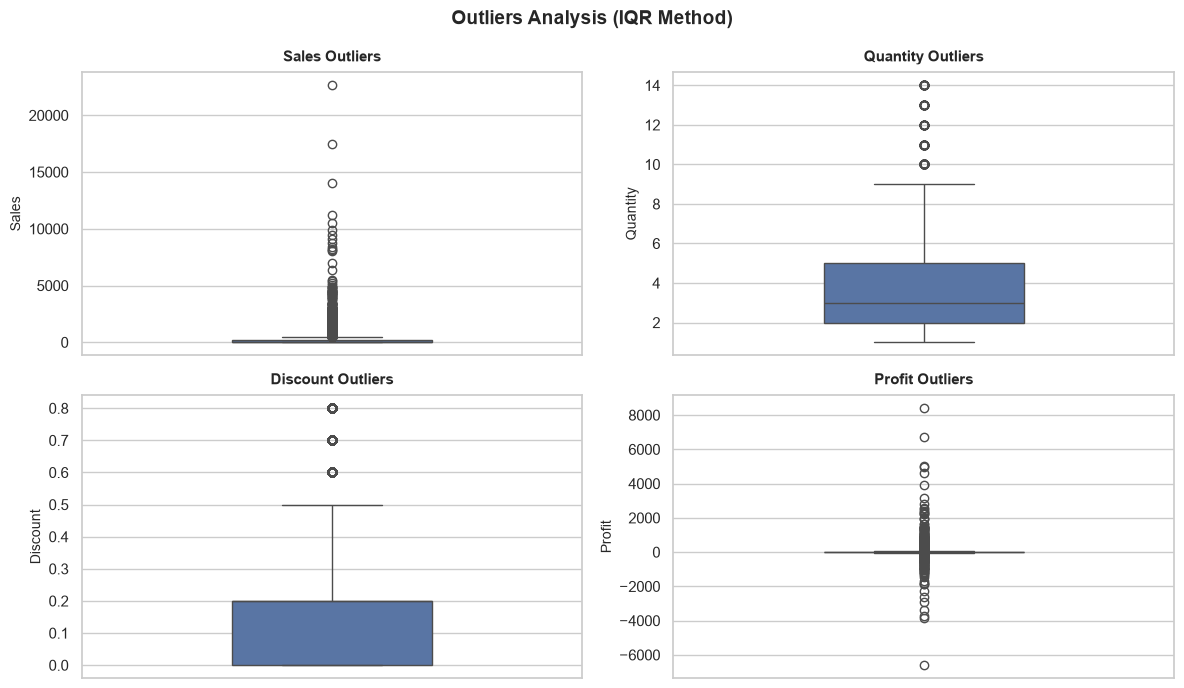

In [22]:

# 1. دالة حساب الـ Outliers
def outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (df[col] < lower) | (df[col] > upper)


# طباعة الأعداد
cols = ["Sales", "Quantity", "Discount", "Profit"]
for col in cols:
    print(f"{col} Outliers: {outliers(orders_df, col).sum()}")

# 2. الرسم البياني بتنسيق بسيط ومريح
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

metrics = [
    ("Sales", axes[0, 0]),
    ("Quantity", axes[0, 1]),
    ("Discount", axes[1, 0]),
    ("Profit", axes[1, 1]),
]

for col, ax in metrics:
    sns.boxplot(y=orders_df[col].dropna(), ax=ax, color="#4C72B0", width=0.4)
    ax.set_title(f"{col} Outliers", fontsize=11, fontweight="bold", pad=8)
    ax.set_ylabel(col, fontsize=10)

fig.suptitle(
    "Outliers Analysis (IQR Method)", fontsize=14, fontweight="bold", y=0.98
)
plt.tight_layout()
plt.show()

# Decision Note: No outliers were removed because they represent valid transactions.

In [6]:
# 5. Feature Engineering (Basic + Advanced)
# Original Features
orders_df["Shipping days"] = (orders_df["Ship Date"] - orders_df["Order Date"]).dt.days
orders_df["Order year"] = orders_df["Order Date"].dt.year
orders_df["Profit Margin"] = (orders_df["Profit"] / orders_df["Sales"]) * 100
orders_df["Profit Category"] = np.where(orders_df["Profit"] >= 0, "Profitable", "Loss")
orders_df["Discount Level"] = pd.cut(orders_df["Discount"], bins=[-0.1, 0, 0.3, 0.5, 0.8, 1.0], labels=["No Discount", "Low", "Medium", "High", "Very High"])
orders_df["Quantity Level"] = pd.cut(orders_df["Quantity"], bins=[0, 4, 8, 12, 14], labels=["Low", "Medium", "High", "Very High"])
orders_df["Shipping Level"] = pd.cut(orders_df["Shipping days"], bins=[-1, 2, 4, 15], labels=["Fast", "Normal", "Slow"])

# Advanced Features
discount_denom = np.where(orders_df["Discount"] == 1, np.nan, (1 - orders_df["Discount"]))
orders_df["Original Unit Price"] = (orders_df["Sales"] / discount_denom) / orders_df["Quantity"]
orders_df["Cost"] = orders_df["Sales"] - orders_df["Profit"]
orders_df["Unit Cost"] = orders_df["Cost"] / orders_df["Quantity"]

orders_df["Order Month"] = orders_df["Order Date"].dt.month
orders_df["Order Quarter"] = orders_df["Order Date"].dt.to_period("Q").astype(str)
orders_df["YearMonth"] = orders_df["Order Date"].dt.to_period("M").astype(str)

# RFM Customer Calculations (Safely transformed without duplicate merge risks)
orders_df["Total_Customer_Sales"] = orders_df.groupby("Customer ID")["Sales"].transform("sum")
orders_df["Total_Customer_Orders"] = orders_df.groupby("Customer ID")["Order ID"].transform("nunique")
orders_df["Last_Order_Date"] = orders_df.groupby("Customer ID")["Order Date"].transform("max")
orders_df["Customer Segment Value"] = pd.qcut(orders_df["Total_Customer_Sales"], q=3, labels=["Low Value", "Medium Value", "High Value"], duplicates="drop")

print("Shape after Feature Engineering:", orders_df.shape)
display(orders_df.head(3))

Shape after Feature Engineering: (9994, 39)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Original Unit Price,Cost,Unit Cost,Order Month,Order Quarter,YearMonth,Total_Customer_Sales,Total_Customer_Orders,Last_Order_Date,Customer Segment Value
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,130.98,220.0464,110.0232,11,2018Q4,2018-11,1148.780,3,2019-01-26,Low Value
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,243.98,512.3580,170.7860,11,2018Q4,2018-11,1148.780,3,2019-01-26,Low Value
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,7.31,7.7486,3.8743,6,2018Q2,2018-06,1119.483,5,2019-12-11,Low Value


In [7]:
# 6. Exploratory Data Analysis (EDA) - Grouping & Aggregations
print("Average sales =", orders_df["Sales"].mean())
print("Average profit =", orders_df["Profit"].mean())
print("Total sales =", orders_df["Sales"].sum())
print("Total profit =", orders_df["Profit"].sum())

def grouping(df, colmn, based_on):
    return df.groupby(colmn)[based_on].sum().sort_values()

print("\nCity Sales Groups:\n", grouping(orders_df, "City", "Sales").tail())
print("="*40)
print("City Profits Groups:\n", grouping(orders_df, "City", "Profit").tail())
print("="*40)
print("Ship Mode Sales Groups:\n", grouping(orders_df, "Ship Mode", "Sales"))
print("="*40)
print("Ship Mode Profits Groups:\n", grouping(orders_df, "Ship Mode", "Profit"))
print("="*40)
print("Category Sales Groups:\n", grouping(orders_df, "Category", "Sales"))
print("="*40)
print("Category Profits Groups:\n", grouping(orders_df, "Category", "Profit"))
print("="*40)
print("Sub-Category Sales Groups:\n", grouping(orders_df, "Sub-Category", "Sales"))
print("="*40)
sub_category_frofit = grouping(orders_df, "Sub-Category", "Profit")
print("Sub-Category Profit Groups:\n", sub_category_frofit)
print("="*40)
print("Segment Sales Groups:\n", grouping(orders_df, "Segment", "Sales"))
print("="*40)
print("Segment Profit Groups:\n", grouping(orders_df, "Segment", "Profit"))

sales_per_year = grouping(orders_df, "Order year", "Sales")
profits_per_year = grouping(orders_df, "Order year", "Profit")
print("\nSales Per Year:\n", sales_per_year)
print("Profits Per Year:\n", profits_per_year)

Average sales = 229.85800083049827
Average profit = 28.656896307784663
Total sales = 2297200.8603
Total profit = 286397.0216999999

City Sales Groups:
 City
Philadelphia     109077.013
San Francisco    112669.092
Seattle          119540.742
Los Angeles      175851.341
New York City    256368.161
Name: Sales, dtype: float64
City Profits Groups:
 City
Detroit          13181.7908
San Francisco    17507.3854
Seattle          29156.0967
Los Angeles      30440.7579
New York City    62036.9837
Name: Profit, dtype: float64
Ship Mode Sales Groups:
 Ship Mode
Same Day          1.283631e+05
First Class       3.514284e+05
Second Class      4.591936e+05
Standard Class    1.358216e+06
Name: Sales, dtype: float64
Ship Mode Profits Groups:
 Ship Mode
Same Day           15891.7589
First Class        48969.8399
Second Class       57446.6354
Standard Class    164088.7875
Name: Profit, dtype: float64
Category Sales Groups:
 Category
Office Supplies    719047.0320
Furniture          741999.7953
Technology 

In [8]:
# 7. Key Performance Indicators (KPIs Summary)
total_sales = orders_df['Sales'].sum()
total_profit = orders_df['Profit'].sum()
total_orders = orders_df['Order ID'].nunique()
overall_profit_margin = (total_profit / total_sales) * 100
aov = total_sales / total_orders
unprofitable_orders = orders_df[orders_df['Profit'] < 0]['Order ID'].nunique()
unprofitable_ratio = (unprofitable_orders / total_orders) * 100
high_discount_loss = orders_df[orders_df['Discount'] > 0.20]['Profit'].sum()

print("="*50)
print("          KEY BUSINESS METRICS (KPIs)          ")
print("="*50)
print(f"Total Sales:                ${total_sales:,.2f}")
print(f"Total Profit:               ${total_profit:,.2f}")
print(f"Overall Profit Margin:      {overall_profit_margin:.2f}%")
print(f"Average Order Value (AOV):  ${aov:,.2f}")
print(f"Unprofitable Orders Ratio:  {unprofitable_ratio:.2f}%")
print(f"Loss from Discount >20%:    ${high_discount_loss:,.2f}")
print("="*50)

          KEY BUSINESS METRICS (KPIs)          
Total Sales:                $2,297,200.86
Total Profit:               $286,397.02
Overall Profit Margin:      12.47%
Average Order Value (AOV):  $458.61
Unprofitable Orders Ratio:  26.31%
Loss from Discount >20%:    $-135,376.06


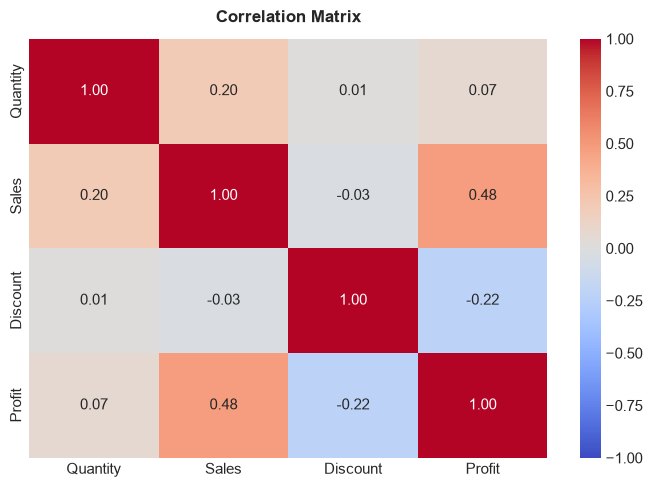

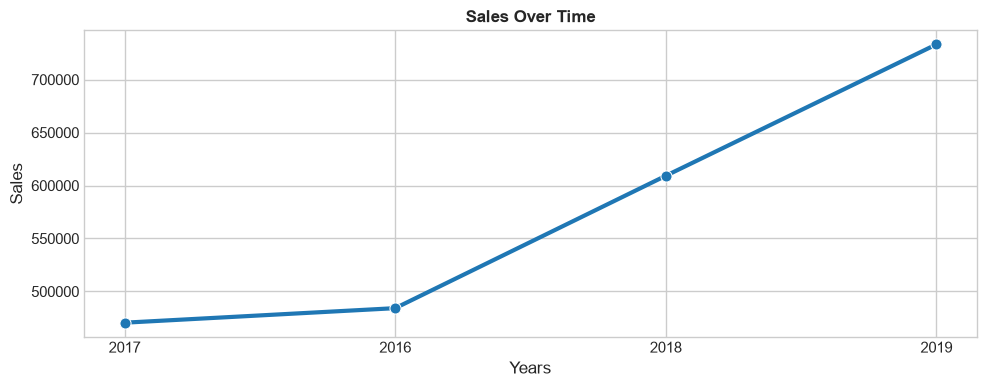

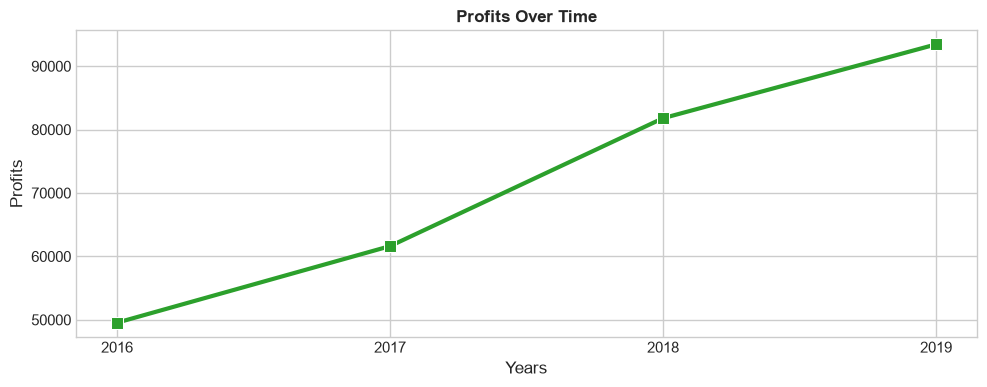

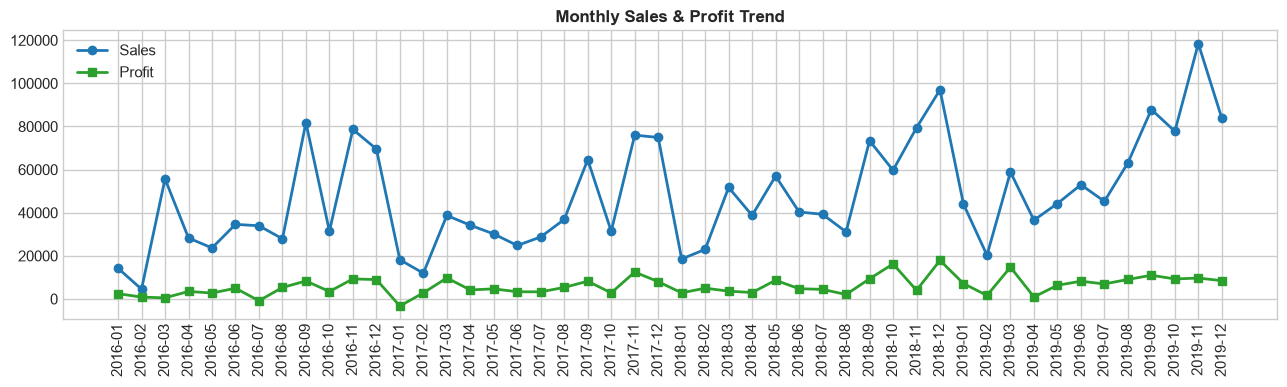

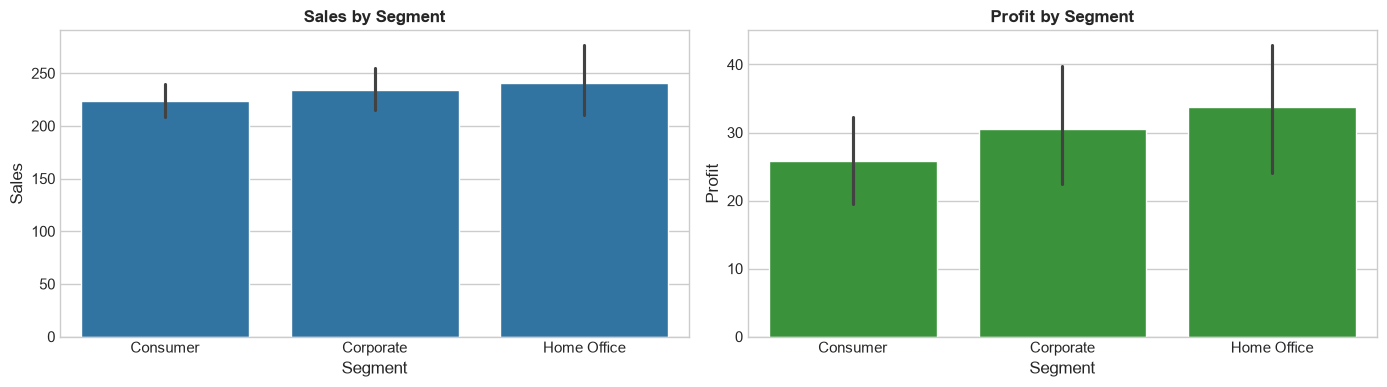

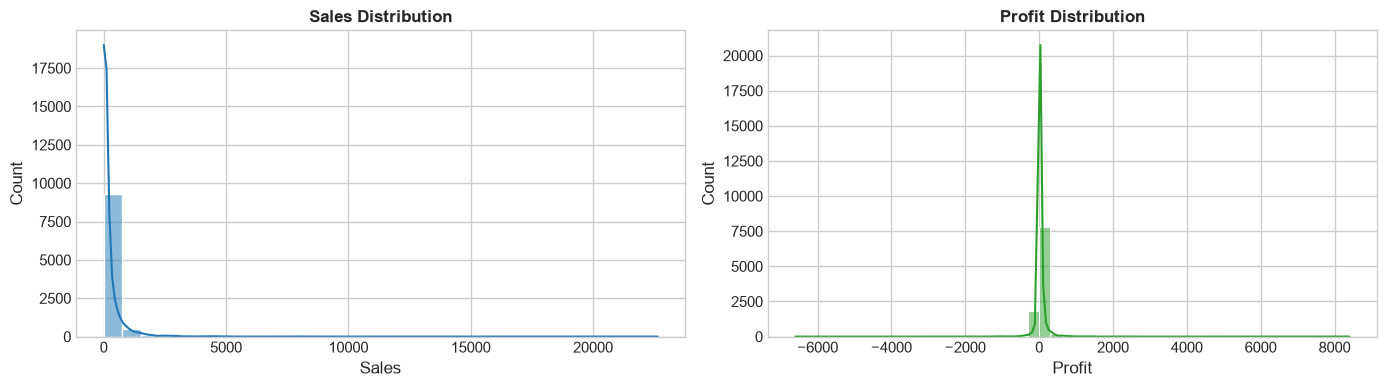

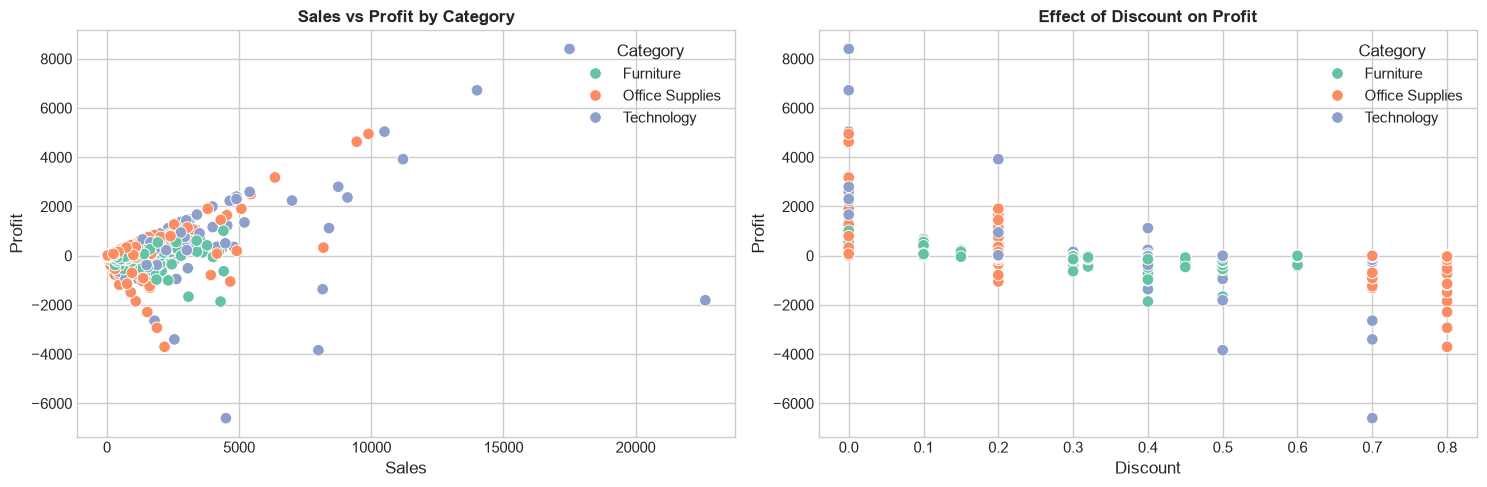

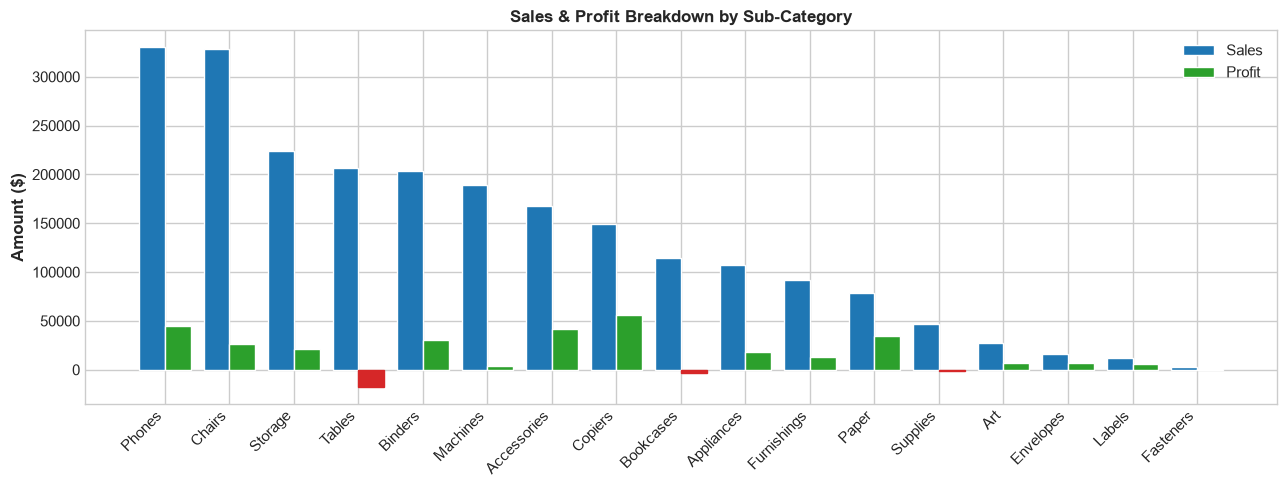

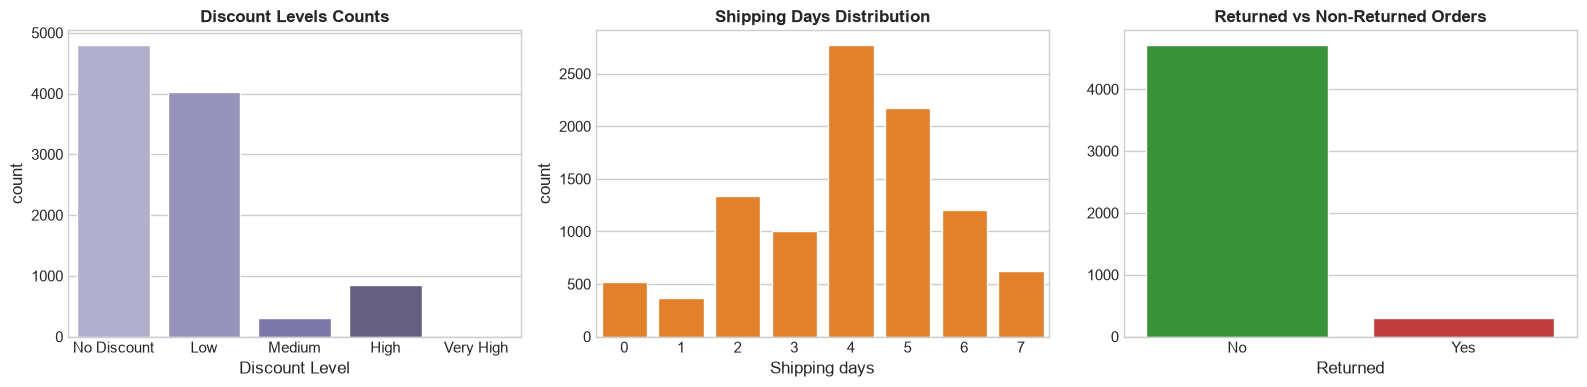

In [11]:
# 8. Complete & Unified Visualizations Section

# 1. Correlation Matrix
plt.figure(figsize=(7, 5))
corr = orders_df[["Quantity", "Sales", "Discount", "Profit"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# 2. Sales Over Time (Line plot)
plt.figure(figsize=(10, 4))
sns.lineplot(x=sales_per_year.index.astype(str), y=sales_per_year.values, linewidth=3, marker="o", markersize=8, color=COLOR_PRIMARY)
plt.title("Sales Over Time", fontweight="bold")
plt.xlabel("Years")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

# 3. Profits Over Time (Line plot)
plt.figure(figsize=(10, 4))
sns.lineplot(x=profits_per_year.index.astype(str), y=profits_per_year.values, linewidth=3, marker="s", markersize=8, color=COLOR_SUCCESS)
plt.title("Profits Over Time", fontweight="bold")
plt.xlabel("Years")
plt.ylabel("Profits")
plt.tight_layout()
plt.show()

# 4. Monthly Trend (Advanced Time Series)
monthly_trend = orders_df.groupby('YearMonth')[['Sales', 'Profit']].sum().reset_index()
plt.figure(figsize=(13, 4))
plt.plot(monthly_trend['YearMonth'], monthly_trend['Sales'], marker='o', label='Sales', color=COLOR_PRIMARY, linewidth=2)
plt.plot(monthly_trend['YearMonth'], monthly_trend['Profit'], marker='s', label='Profit', color=COLOR_SUCCESS, linewidth=2)
plt.xticks(rotation=90)
plt.title('Monthly Sales & Profit Trend', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Sales & Profit by Segment
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=orders_df, x="Segment", y="Sales", ax=ax[0], color=COLOR_PRIMARY)
ax[0].set_title("Sales by Segment", fontweight="bold")

sns.barplot(data=orders_df, x="Segment", y="Profit", ax=ax[1], color=COLOR_SUCCESS)
ax[1].set_title("Profit by Segment", fontweight="bold")
plt.tight_layout()
plt.show()

# 6. Sales and Profit Distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=orders_df, x="Sales", bins=30, ax=ax[0], color=COLOR_PRIMARY, kde=True)
ax[0].set_title("Sales Distribution", fontweight="bold")

sns.histplot(data=orders_df, x="Profit", bins=50, ax=ax[1], color=COLOR_SUCCESS, kde=True)
ax[1].set_title("Profit Distribution", fontweight="bold")
plt.tight_layout()
plt.show()

# 7. Scatter Plots: Sales vs Profit & Discount Effect
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=orders_df, x="Sales", y="Profit", hue="Category", s=70, ax=ax[0], palette="Set2")
ax[0].set_title("Sales vs Profit by Category", fontweight="bold")

sns.scatterplot(data=orders_df, x="Discount", y="Profit", hue="Category", s=70, ax=ax[1], palette="Set2")
ax[1].set_title("Effect of Discount on Profit", fontweight="bold")
plt.tight_layout()
plt.show()



# 8. Sub-Category Sales & Profit Comparison Barplot
subcat = orders_df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False).reset_index()
plt.figure(figsize=(13, 5))
x = np.arange(len(subcat))
plt.bar(x - 0.2, subcat['Sales'], 0.4, label='Sales', color=COLOR_PRIMARY)
profit_bars = plt.bar(x + 0.2, subcat['Profit'], 0.4, label='Profit', color=COLOR_SUCCESS)
for i, p in enumerate(subcat['Profit']):
    if p < 0:
        profit_bars[i].set_color(COLOR_DANGER)
plt.xticks(x, subcat['Sub-Category'], rotation=45, ha='right')
plt.ylabel('Amount ($)', fontweight='bold')
plt.title('Sales & Profit Breakdown by Sub-Category', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# 9. Counts: Discount Levels, Shipping Days, and Returns
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=orders_df, x="Discount Level", ax=ax[0], palette="Purples_d")
ax[0].set_title("Discount Levels Counts", fontweight="bold")

sns.countplot(data=orders_df, x="Shipping days", ax=ax[1], color=COLOR_ACCENT)
ax[1].set_title("Shipping Days Distribution", fontweight="bold")

return_counts = orders_df.groupby("Returned")["Order ID"].nunique()
sns.barplot(x=return_counts.index, y=return_counts.values, ax=ax[2], palette=["#2ca02c", "#d62728"])
ax[2].set_title("Returned vs Non-Returned Orders", fontweight="bold")
plt.tight_layout()
plt.show()

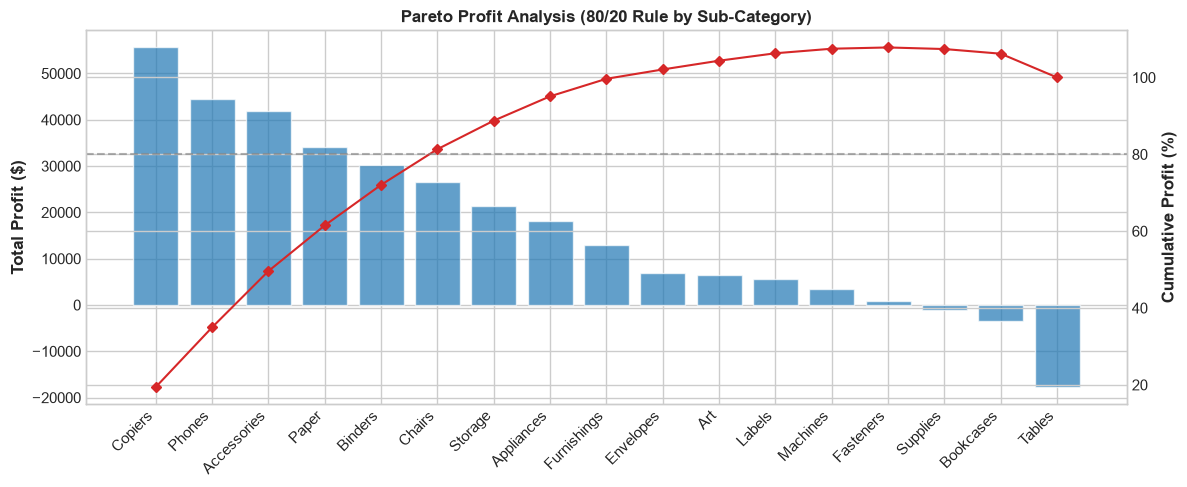

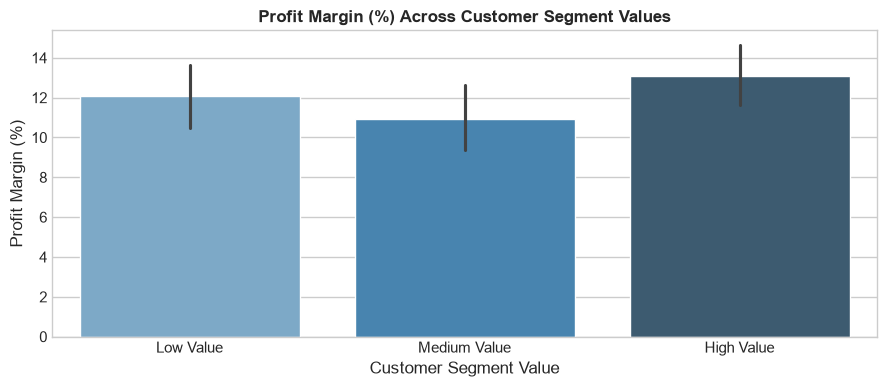

In [ ]:
# 10. Advanced Strategic Business Insights & Pareto Analysis

# أ. تحليل قاعدة 80/20 للأرباح حسب الفئات الفرعية (Pareto Analysis)
subcat_profit = (
    orders_df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
subcat_profit["Cumulative_Profit"] = subcat_profit["Profit"].cumsum()
subcat_profit["Cumulative_%"] = (
    subcat_profit["Cumulative_Profit"] / subcat_profit["Profit"].sum()
) * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(
    subcat_profit["Sub-Category"],
    subcat_profit["Profit"],
    color=COLOR_PRIMARY,
    alpha=0.7,
)
ax2.plot(
    subcat_profit["Sub-Category"],
    subcat_profit["Cumulative_%"],
    color=COLOR_DANGER,
    marker="D",
    ms=5,
)

ax1.set_xticklabels(subcat_profit["Sub-Category"], rotation=45, ha="right")
ax1.set_ylabel("Total Profit ($)", fontweight="bold")
ax2.set_ylabel("Cumulative Profit (%)", fontweight="bold")
ax2.axhline(80, color="gray", linestyle="--", alpha=0.6)
plt.title(
    "Pareto Profit Analysis (80/20 Rule by Sub-Category)", fontweight="bold"
)
plt.tight_layout()
plt.show()

# ب. تحليل الربحية حسب تصنيف العملاء (Customer Segment Value)
plt.figure(figsize=(9, 4))
sns.barplot(
    data=orders_df,
    x="Customer Segment Value",
    y="Profit Margin",
    palette="Blues_d",
)
plt.title(
    "Profit Margin (%) Across Customer Segment Values", fontweight="bold"
)
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

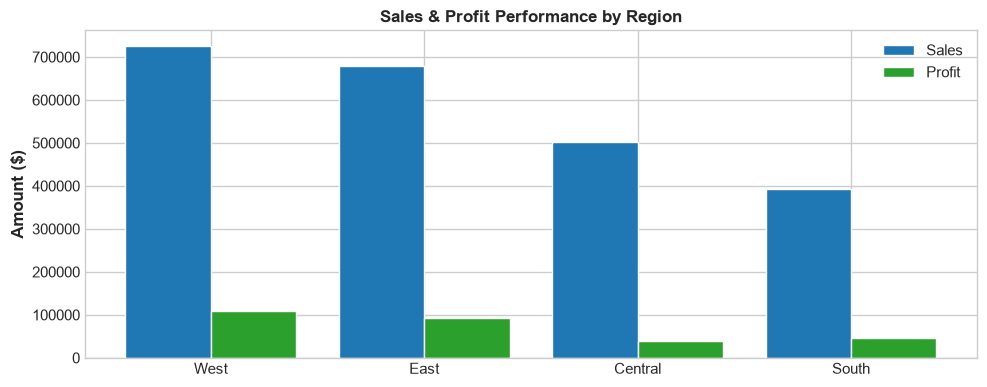

In [ ]:
# . Geographic Performance Analysis (Sales & Profit by Region)
region_perf = (
    orders_df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values(by="Sales", ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 4))
x = np.arange(len(region_perf))
plt.bar(x - 0.2, region_perf["Sales"], 0.4, label="Sales", color=COLOR_PRIMARY)
plt.bar(x + 0.2, region_perf["Profit"], 0.4, label="Profit", color=COLOR_SUCCESS)

plt.xticks(x, region_perf["Region"])
plt.ylabel("Amount ($)", fontweight="bold")
plt.title("Sales & Profit Performance by Region", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()